In [219]:
import pyMMF
import numpy as np
import matplotlib.pyplot as plt

In [220]:
NA = 0.1
radius = 5 # in microns
areaSize = 2.5*radius # calculate the field on an area larger than the diameter of the fiber
npoints = 2**7 # resolution of the window
n1 = 1.4585
wl = 0.532 # wavelength in microns
curvature = None

In [221]:
profile = pyMMF.IndexProfile(npoints = npoints, areaSize = areaSize)

In [222]:
profile.initParabolicGRIN(n1=n1, a=radius, NA=NA)

In [223]:
solver = pyMMF.propagationModeSolver()
solver.setIndexProfile(profile)
solver.setWL(wl)

2023-11-10 21:58:41,612 - pyMMF.core [DEBUG  ]  Debug mode ON.


In [224]:
NmodesMax = pyMMF.estimateNumModesGRIN(wl,radius,NA)

In [225]:
modes = solver.solve(nmodesMax=NmodesMax+10,
                     boundary = 'close',
                     mode = 'eig',
                     curvature = curvature)

2023-11-10 21:58:41,990 - pyMMF.solv [INFO   ]  Solving the spatial eigenvalue problem for mode finding.
2023-11-10 21:58:41,991 - pyMMF.solv [INFO   ]  Use close boundary condition.
2023-11-10 21:58:44,875 - pyMMF.solv [INFO   ]  Solver found 3 modes is 2.89 seconds.
2023-11-10 21:58:44,877 - pyMMF.core [DEBUG  ]  Mode data stored in memory.


In [226]:
modes = solver.solve(mode = 'radial')

2023-11-10 21:58:44,904 - pyMMF.solv [INFO   ]  Found 2 radial mode(s) for m=0
2023-11-10 21:58:44,905 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2023-11-10 21:58:44,909 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 2
2023-11-10 21:58:44,934 - pyMMF.solv [INFO   ]  Found 1 radial mode(s) for m=1
2023-11-10 21:58:44,936 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2023-11-10 21:58:44,957 - pyMMF.solv [INFO   ]  Found 1 radial mode(s) for m=2
2023-11-10 21:58:44,959 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2023-11-10 21:58:44,976 - pyMMF.solv [INFO   ]  Found 0 radial mode(s) for m=3
2023-11-10 21:58:44,978 - pyMMF.solv [INFO   ]  Solver found 6 modes is 0.09 seconds.
2023-11-10 21:58:44,979 - pyMMF.core [DEBUG  ]  Mode data stored in memory.


In [227]:
Nmodes = modes.number

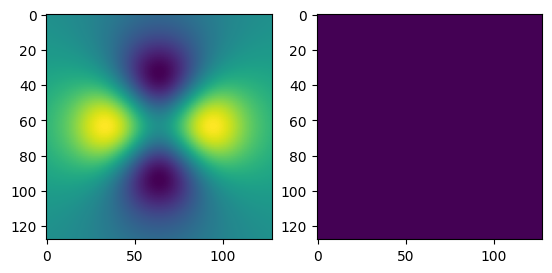

In [228]:
Nmodes = modes.number
m = 4
plt.figure()
plt.subplot(121)
plt.imshow(np.real(modes.profiles[m]).reshape([npoints] * 2))
plt.subplot(122)
plt.imshow(np.imag(modes.profiles[m]).reshape([npoints] * 2))
